# PPE Compliance Checker — Multi-Agent Computer Vision System
### ITAI 1378 — Computer Vision Capstone Project (Tier 3)

**Team Members**
- Eva Abou Harb
- Mary Ann Mastri
- Zain Ahmed

## What this notebook does
A three-agent pipeline built around a custom-trained YOLO11 object detector:

| Agent | Role | Input → Output |
|---|---|---|
| **Perception Agent** | Runs the fine-tuned YOLO11 ONNX model on an image | image → list of `{class, confidence, bbox}` detections |
| **Compliance Agent** | Rule-based reasoning over detections | detections → `{compliant, violations, missing, detected}` |
| **Reporter Agent** | Produces the useful output | compliance result → annotated image + JSON report (and a console alert for violations) |

The agents communicate through a fixed message schema (plain Python dicts / JSON) — each
agent only sees the structured output of the one before it, never raw pixels it didn't
produce itself (except the Perception Agent, which is the only one that touches the image).

## Dataset
This notebook trains on Ultralytics' own **[Construction-PPE dataset](https://docs.ultralytics.com/datasets/detect/construction-ppe)**
— 1,416 images (1,132 train / 143 val / 141 test), 178.4 MB, 11 classes covering both
worn PPE and explicit "missing PPE" labels:

- **Worn**: `helmet, gloves, vest, boots, goggles`
- **Missing/violation**: `no_helmet, no_gloves, no_boots, no_goggle`
- **Other**: `Person, none`

**No API keys, tokens, or logins are required to run this notebook.** Ultralytics'
own training code downloads this dataset automatically the first time you reference
`construction-ppe.yaml` — it fetches a public zip straight from a GitHub release and
unpacks it. There's no custom download code to break here at all.

An earlier draft of this notebook used a different, much larger (668MB) public PPE
dataset from Hugging Face, which kept disconnecting free-tier Colab runtimes during
download. This one is roughly a quarter of the size and downloads in well under a
minute.


## 1. Environment Check

In [1]:
# ============================
# Cell 1.0 - Environment Check
# ============================
# Purpose: confirm GPU / RAM / Torch availability before doing anything heavy.

import os

try:
    gpu_info = os.popen("nvidia-smi").read()
    print(gpu_info if "NVIDIA-SMI" in gpu_info else "No GPU detected via nvidia-smi.")
except Exception as e:
    print("nvidia-smi not available:", e)


Sun Aug  9 04:19:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import psutil, torch

print(f"RAM used: {psutil.virtual_memory().used / (1024**3):.2f} GB")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif "COLAB_TPU_ADDR" in os.environ:
    device = torch.device("xla")
    print("TPU runtime detected")
else:
    device = torch.device("cpu")
    print("No GPU/TPU detected, running on CPU (training will be slow).")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


RAM used: 1.23 GB
Using GPU: Tesla T4
Torch version: 2.11.0+cu128
CUDA available: True


## 2. Install Dependencies

In [3]:
# ============================
# Cell 2.0 - Install Dependencies
# ============================
# Only run this once per runtime. Re-running is harmless (pip no-ops on satisfied reqs).

%pip install --quiet ultralytics onnx onnxruntime opencv-python-headless pyyaml matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 43.2 MB/s eta 0:00:00


## 3. Dataset — Download & Explore (Public, No Secrets, ~178MB)

Ultralytics ships a ready-to-use `construction-ppe.yaml` config that points at a public
GitHub release zip. Calling `check_det_dataset()` (the same function `model.train()` calls
internally) downloads and unpacks it the first time, and gives us back the resolved local
paths so we can explore the data before training. No manual zip handling, no Drive
dependency, no API key.


In [4]:
# ============================
# Cell 3.0 - Download + resolve the Construction-PPE dataset
# ============================
from ultralytics.data.utils import check_det_dataset

DATA_YAML = "construction-ppe.yaml"  # bundled with ultralytics; auto-downloads on first use

data_info = check_det_dataset(DATA_YAML)

CLASS_NAMES = list(data_info["names"].values()) if isinstance(data_info["names"], dict) else list(data_info["names"])
TRAIN_IMAGES_PATH = str(data_info["train"])
VAL_IMAGES_PATH = str(data_info["val"])
TEST_IMAGES_PATH = str(data_info.get("test") or data_info["val"])

print("Dataset ready.")
print("Classes:", CLASS_NAMES)
print("Train images dir:", TRAIN_IMAGES_PATH)
print("Val images dir:  ", VAL_IMAGES_PATH)
print("Test images dir: ", TEST_IMAGES_PATH)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'construction-ppe.yaml' images not found, missing path '/content/datasets/construction-ppe/images/val'
Unzipping /content/datasets/construction-ppe.zip to /content/datasets/construction-ppe...: 100% ━━━━━━━━━━━━ 2852/2852 1.0Kfiles/s 2.8s
Dataset download success ✅ (4.0s), saved to /content/datasets

Dataset ready.
Classes: ['helmet', 'gloves', 'vest', 'boots', 'goggles', 'none', 'Person', 'no_helmet', 'no_goggle', 'no_gloves', 'no_boots']
Train images dir: /content/datasets/construction-ppe/images/train
Val images dir:   /content/datasets/construction-ppe/images/val
Test images dir:  /content/datasets/construction-ppe/images/test


In [5]:
# ============================
# Cell 3.1 - Verify Dataset Structure
# ============================
# Purpose: confirm every split actually has images + matching label files.

def labels_dir_for(images_dir):
    # Ultralytics YOLO datasets mirror .../images/<split> with .../labels/<split>
    return images_dir.replace(f"{os.sep}images{os.sep}", f"{os.sep}labels{os.sep}")

print("Dataset Summary")
print("-" * 40)

_incomplete = []
for split_name, images_path in [("train", TRAIN_IMAGES_PATH), ("val", VAL_IMAGES_PATH), ("test", TEST_IMAGES_PATH)]:
    labels_path = labels_dir_for(images_path)
    if not os.path.isdir(images_path):
        print(f"WARNING: {split_name} images folder missing at {images_path}")
        _incomplete.append(split_name)
        continue
    n_images = len([f for f in os.listdir(images_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    n_labels = len([f for f in os.listdir(labels_path) if f.lower().endswith(".txt")]) if os.path.isdir(labels_path) else 0
    print(f"{split_name:>6}: {n_images} images, {n_labels} label files")
    if n_images == 0:
        _incomplete.append(split_name)

if _incomplete:
    raise FileNotFoundError(f"Split(s) {_incomplete} are missing or empty. Re-run Cell 3.0.")
else:
    print("\nAll splits verified. Safe to proceed.")


Dataset Summary
----------------------------------------
 train: 1132 images, 1142 label files
   val: 143 images, 143 label files
  test: 141 images, 141 label files

All splits verified. Safe to proceed.


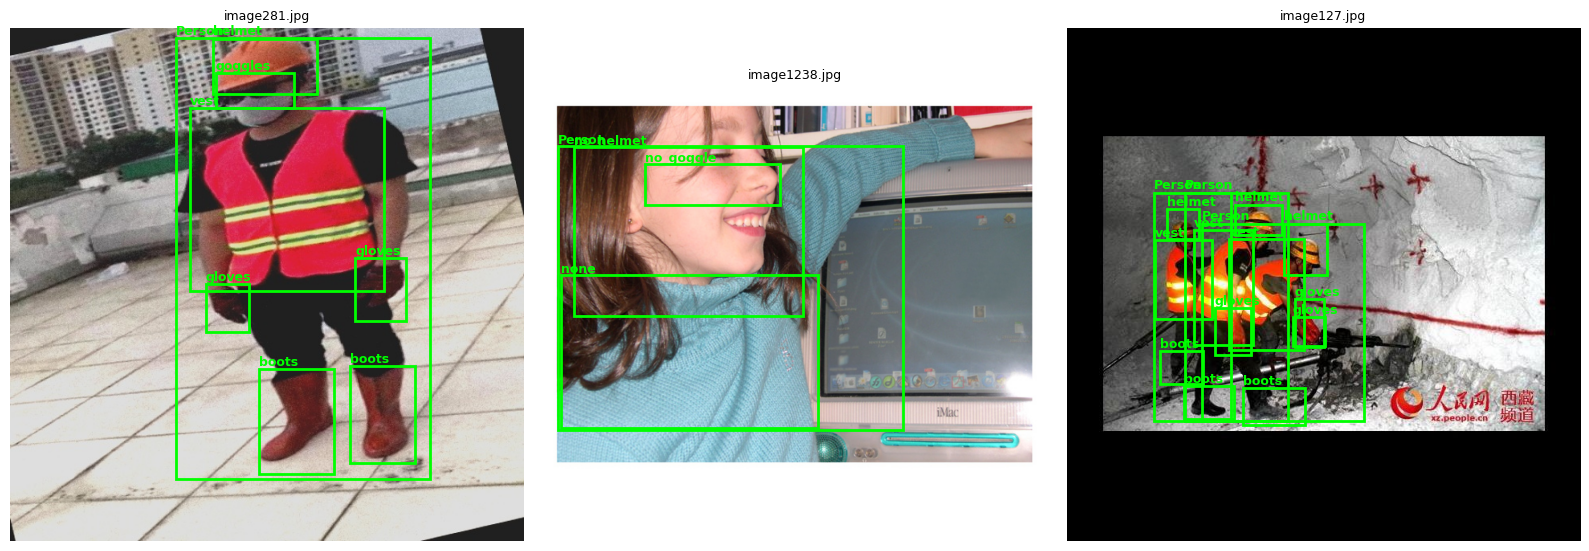

In [6]:
# ============================
# Cell 3.2 - Visual Sanity Check
# ============================
# Purpose: display a few random training images with their YOLO bounding boxes drawn.

import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

train_labels_path = labels_dir_for(TRAIN_IMAGES_PATH)
all_images = [f for f in os.listdir(TRAIN_IMAGES_PATH) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

if len(all_images) >= 3:
    sample_images = random.sample(all_images, 3)
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    for ax, img_file in zip(axes, sample_images):
        img = cv2.imread(os.path.join(TRAIN_IMAGES_PATH, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        label_path = os.path.join(train_labels_path, os.path.splitext(img_file)[0] + ".txt")
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.split()
                    if len(parts) < 5:
                        continue
                    cls_id, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:5])
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    rect = patches.Rectangle((x1, y1), bw * w, bh * h, linewidth=2, edgecolor="lime", facecolor="none")
                    ax.add_patch(rect)
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    ax.text(x1, max(y1 - 5, 0), label, color="lime", fontsize=9, weight="bold")
        ax.set_title(img_file, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough training images found for a sanity check.")


## 4. (Optional) Persist Results to Your Own Google Drive

Purely a convenience — if you're in Colab and want your trained weights to survive a
runtime reset, mount your own Drive here. Skipping this is completely fine; training
just saves to the ephemeral `/content/runs` instead.


In [7]:
# ============================
# Cell 4.0 - Optional Drive mount for saving results
# ============================
PROJECT_DIR = "/content/runs"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/MyDrive/PPE_Compliance_Checkpoints"
    os.makedirs(PROJECT_DIR, exist_ok=True)
    print(f"Drive mounted. Training results will be saved to: {PROJECT_DIR}")
except Exception:
    print("Not running in Colab (or Drive mount skipped) — results will save to /content/runs instead.")


Mounted at /content/drive
Drive mounted. Training results will be saved to: /content/drive/MyDrive/PPE_Compliance_Checkpoints


## 5. Train YOLO11n on Construction-PPE

In [ ]:
# ============================
# Cell 5.0 - Train YOLO11n
# ============================
from ultralytics import YOLO

RUN_NAME = "yolo11_ppe_training"

model = YOLO("yolo11n.pt")  # lightweight checkpoint, pretrained on COCO

results = model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=320,
    batch=16,
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    patience=10,
)

WEIGHTS_DIR = os.path.join(PROJECT_DIR, RUN_NAME, "weights")
BEST_PT = os.path.join(WEIGHTS_DIR, "best.pt")
print("\nTraining complete. Best weights at:", BEST_PT)


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_ppe_training, nbs=64, nms=False, o

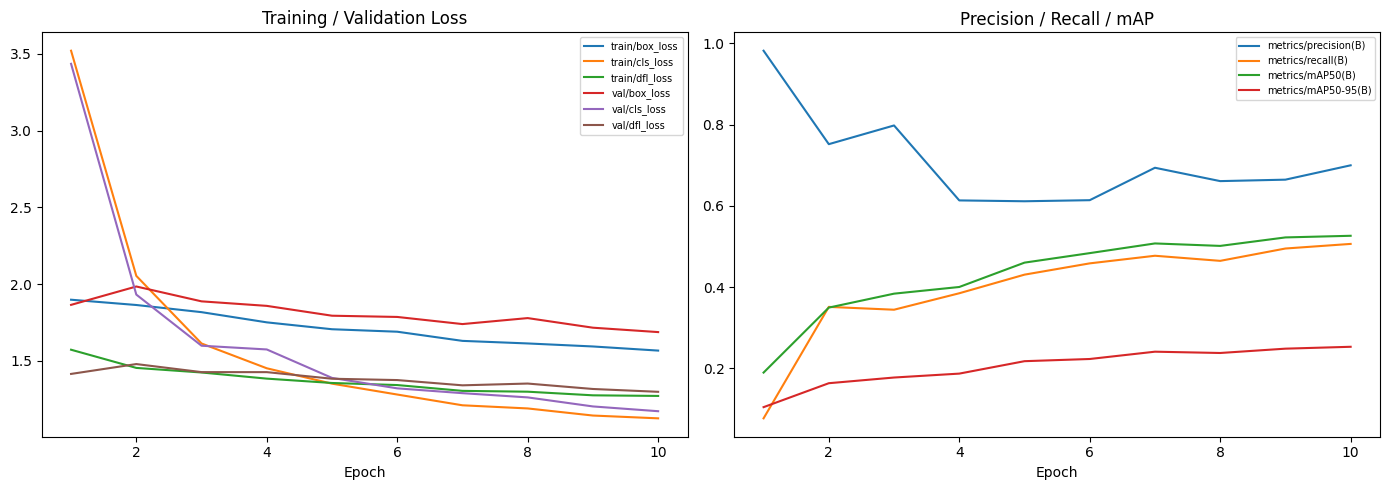

In [10]:
# ============================
# Cell 5.1 - Training Curves
# ============================
import pandas as pd

results_csv = os.path.join(PROJECT_DIR, RUN_NAME, "results.csv")

if not os.path.exists(results_csv):
    print(f"results.csv not found at {results_csv} — did training run in Cell 5.0?")
else:
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    loss_cols = [c for c in df.columns if "loss" in c]
    for c in loss_cols:
        axes[0].plot(df["epoch"], df[c], label=c)
    axes[0].set_title("Training / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(fontsize=7)

    metric_cols = [c for c in df.columns if "precision" in c or "recall" in c or "mAP" in c]
    for c in metric_cols:
        axes[1].plot(df["epoch"], df[c], label=c)
    axes[1].set_title("Precision / Recall / mAP")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()


In [11]:
# ============================
# Cell 5.2 - Evaluate Best Model on Validation Set
# ============================
if not os.path.exists(BEST_PT):
    print(f"best.pt not found at {BEST_PT}. Run Cell 5.0 (training) first.")
else:
    eval_model = YOLO(BEST_PT)
    metrics = eval_model.val(data=DATA_YAML)

    metrics_path = os.path.join(WEIGHTS_DIR, "evaluation_metrics.txt")
    with open(metrics_path, "w") as f:
        f.write(f"mAP50: {metrics.box.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.box.map:.4f}\n")
        f.write(f"Mean Precision: {metrics.box.mp:.4f}\n")
        f.write(f"Mean Recall: {metrics.box.mr:.4f}\n")

    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Mean Precision: {metrics.box.mp:.4f}")
    print(f"Mean Recall: {metrics.box.mr:.4f}")
    print("\nSaved to:", metrics_path)


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2690.7±861.0 MB/s, size: 194.0 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 40.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.7s
                   all        143       1172      0.709      0.504      0.524      0.253
                helmet        107        201      0.786      0.746      0.768      0.403
                gloves         68        136      0.698      0.632      0.672      0.308
                  vest        109        171      0.768       0.83      0.842      0.495
                 boots         64        151      0.735      0.702      0.733      0.401
               goggles        

## 6. Export to ONNX

In [12]:
# ============================
# Cell 6.0 - Export best.pt -> ONNX
# ============================
if not os.path.exists(BEST_PT):
    raise FileNotFoundError(f"best.pt not found at {BEST_PT}. Run Cell 5.0 first.")

export_model = YOLO(BEST_PT)
onnx_path = export_model.export(format="onnx", imgsz=640, simplify=True)
ONNX_MODEL_PATH = str(onnx_path)
print("Exported ONNX model to:", ONNX_MODEL_PATH)


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/PPE_Compliance_Checkpoints/yolo11_ppe_training/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 15, 8400) (5.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 408ms
Prepared 2 packages in 49ms
Installed 2 packages in 6ms
 + colorama==0.4.6
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export s

In [13]:
# ============================
# Cell 6.1 - Verify ONNX Export
# ============================
import onnxruntime as ort

if not os.path.exists(ONNX_MODEL_PATH):
    print(f"ONNX model not found at: {ONNX_MODEL_PATH}")
else:
    ort_session = ort.InferenceSession(ONNX_MODEL_PATH, providers=["CPUExecutionProvider"])
    print("ONNX model loaded successfully.")
    for inp in ort_session.get_inputs():
        print(f"  Input:  {inp.name}, shape={inp.shape}, type={inp.type}")
    for out in ort_session.get_outputs():
        print(f"  Output: {out.name}, shape={out.shape}, type={out.type}")
    ONNX_INPUT_NAME = ort_session.get_inputs()[0].name


ONNX model loaded successfully.
  Input:  images, shape=[1, 3, 640, 640], type=tensor(float)
  Output: output0, shape=[1, 15, 8400], type=tensor(float)


## 7. ONNX Inference Utilities

YOLO11 exports anchor-free detections shaped `(1, 4 + num_classes, num_anchors)` — no
separate objectness score, and the array needs transposing before reading a detection
per row. Preprocessing uses a **letterbox** resize (pads instead of squashing) so boxes
map back to the original image correctly. Everything downstream (single-image demo,
batch inference, benchmarking, and the Tier-3 agents) shares these two functions.


In [14]:
# ============================
# Cell 7.0 - Shared preprocessing + decoding utilities
# ============================
import numpy as np

def letterbox(img, new_size=640, color=(114, 114, 114)):
    """Resize + pad an image to a square, preserving aspect ratio. Returns the padded
    image plus the scale factor and padding offsets needed to map box coordinates back
    to the ORIGINAL image size."""
    h, w = img.shape[:2]
    r = min(new_size / h, new_size / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    resized = cv2.resize(img, (nw, nh))
    canvas = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    top = (new_size - nh) // 2
    left = (new_size - nw) // 2
    canvas[top:top + nh, left:left + nw] = resized
    return canvas, r, left, top


def preprocess(img_rgb, input_size=640):
    canvas, r, left, top = letterbox(img_rgb, input_size)
    tensor = canvas.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))  # HWC -> CHW
    tensor = np.expand_dims(tensor, 0)
    return tensor, r, left, top


def decode_yolo_onnx(output, r, left, top, class_names, conf_thres=0.25, iou_thres=0.45):
    """Decode a YOLO11 ONNX output of shape (1, 4+nc, num_anchors) into a list of
    detections with boxes mapped back to ORIGINAL image coordinates."""
    preds = output[0]  # (4+nc, num_anchors)
    if preds.shape[0] == 4 + len(class_names):
        preds = preds.transpose(1, 0)  # -> (num_anchors, 4+nc)

    boxes_xywh, scores, class_ids = [], [], []
    for row in preds:
        cx, cy, bw, bh = row[:4]
        class_scores = row[4:4 + len(class_names)]
        cid = int(np.argmax(class_scores))
        conf = float(class_scores[cid])
        if conf < conf_thres:
            continue
        x1 = (cx - bw / 2 - left) / r
        y1 = (cy - bh / 2 - top) / r
        w = bw / r
        h = bh / r
        boxes_xywh.append([x1, y1, w, h])
        scores.append(conf)
        class_ids.append(cid)

    detections = []
    if boxes_xywh:
        indices = cv2.dnn.NMSBoxes(boxes_xywh, scores, conf_thres, iou_thres)
        indices = [i[0] if isinstance(i, (list, np.ndarray)) else i for i in indices]
        for i in indices:
            x1, y1, w, h = boxes_xywh[i]
            detections.append({
                "class": class_names[class_ids[i]],
                "conf": round(scores[i], 4),
                "bbox": [round(float(x1), 1), round(float(y1), 1), round(float(x1 + w), 1), round(float(y1 + h), 1)],  # x1,y1,x2,y2
            })
    return detections


def run_onnx_inference(session, input_name, img_path, class_names, conf_thres=0.25, iou_thres=0.45):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor, r, left, top = preprocess(img_rgb)
    outputs = session.run(None, {input_name: tensor})
    detections = decode_yolo_onnx(outputs[0], r, left, top, class_names, conf_thres, iou_thres)
    return detections, img_rgb


print("Utilities ready: letterbox, preprocess, decode_yolo_onnx, run_onnx_inference")


Utilities ready: letterbox, preprocess, decode_yolo_onnx, run_onnx_inference


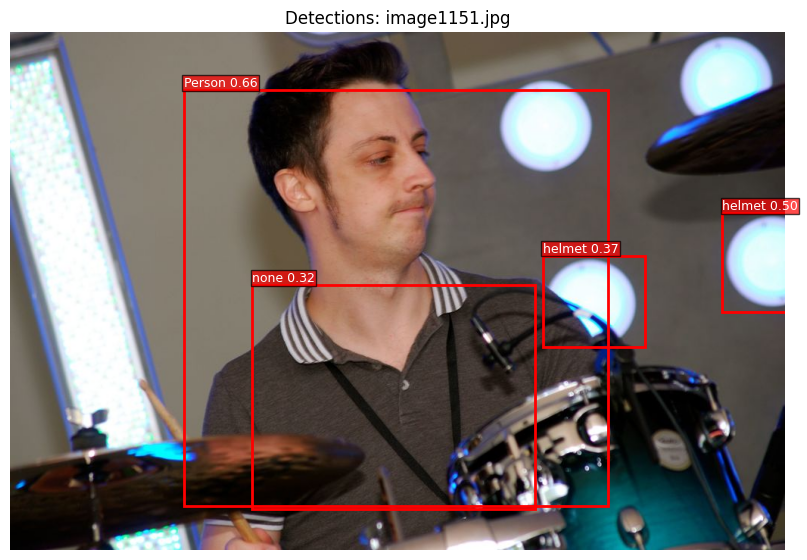


Detected 4 objects:
  - Person (conf=0.6557)
  - helmet (conf=0.5012)
  - helmet (conf=0.3715)
  - none (conf=0.3204)


In [15]:
# ============================
# Cell 7.1 - Single Image Inference Demo
# ============================
val_images = [f for f in os.listdir(VAL_IMAGES_PATH) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
if not val_images:
    print("No validation images found.")
else:
    sample_img = random.choice(val_images)
    sample_path = os.path.join(VAL_IMAGES_PATH, sample_img)
    detections, img_rgb = run_onnx_inference(ort_session, ONNX_INPUT_NAME, sample_path, CLASS_NAMES)

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img_rgb)
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), f"{d['class']} {d['conf']:.2f}", color="white", fontsize=9,
                 bbox=dict(facecolor="red", alpha=0.7, pad=1))
    ax.set_title(f"Detections: {sample_img}")
    ax.axis("off")
    plt.savefig("/content/onnx_inference_preview.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"\nDetected {len(detections)} objects:")
    for d in detections:
        print(f"  - {d['class']} (conf={d['conf']})")


In [16]:
# ============================
# Cell 7.2 - Batch Inference + Speed Benchmark
# ============================
import time

N_BENCH = min(20, len(val_images))
sample_paths = [os.path.join(VAL_IMAGES_PATH, f) for f in random.sample(val_images, N_BENCH)] if val_images else []

times = []
all_detections = []
for p in sample_paths:
    start = time.time()
    dets, _ = run_onnx_inference(ort_session, ONNX_INPUT_NAME, p, CLASS_NAMES)
    times.append(time.time() - start)
    all_detections.append(dets)

if times:
    print(f"Benchmarked on {len(times)} images:")
    print(f"  Mean inference time: {sum(times)/len(times)*1000:.1f} ms")
    print(f"  Min: {min(times)*1000:.1f} ms  Max: {max(times)*1000:.1f} ms")
    total_dets = sum(len(d) for d in all_detections)
    print(f"  Total detections across batch: {total_dets}")


Benchmarked on 20 images:
  Mean inference time: 203.6 ms
  Min: 129.9 ms  Max: 565.8 ms
  Total detections across batch: 110


## 8. Tier 3 Multi-Agent PPE Compliance System

Three agents, each with a distinct role, passing **structured messages** (plain dicts /
JSON) to the next — no agent reaches back into another agent's internals:

```
image ──► [Perception Agent] ──► detections[] ──► [Compliance Agent] ──► compliance{} ──► [Reporter Agent] ──► annotated image + JSON report (+ console alert)
```

- **Perception Agent** — the only agent that touches pixels. Wraps `run_onnx_inference`
  and returns a list of `{class, conf, bbox}` dicts.
- **Compliance Agent** — pure rule-based reasoning, no image access. This dataset's
  11 classes make the rule richer than a simple "is it present" check: it treats an
  explicit `no_helmet` / `no_gloves` / `no_boots` / `no_goggle` detection as a direct
  violation, *and* separately checks whether each required worn-PPE item was seen at all.
- **Reporter Agent** — takes the compliance decision and *acts* on it: saves an
  annotated image, writes a structured JSON report to disk, and prints a console alert
  for any non-compliant scene.


In [17]:
# ============================
# Cell 8.0 - Perception Agent
# ============================
def perception_agent(img_path, session=ort_session, input_name=ONNX_INPUT_NAME,
                      class_names=CLASS_NAMES, conf_thres=0.25):
    """Perceives the world: runs the trained YOLO11 ONNX model on an image and
    returns a structured list of detections. This is the ONLY agent that reads pixels."""
    detections, img_rgb = run_onnx_inference(session, input_name, img_path, class_names, conf_thres)
    return detections, img_rgb


In [18]:
# ============================
# Cell 8.1 - Compliance Agent
# ============================
# Worn PPE we require evidence of; the "no_*" classes are explicit violation flags;
# Person / none are context classes we don't reason over directly.
REQUIRED_PPE = {"helmet", "gloves", "vest", "boots", "goggles"}
VIOLATION_CLASSES = {"no_helmet", "no_gloves", "no_boots", "no_goggle"}

def compliance_agent(detections, required_ppe=REQUIRED_PPE, violation_classes=VIOLATION_CLASSES):
    """Reasons over structured detections (no image access) and decides compliance."""
    detected_classes = {d["class"] for d in detections}
    explicit_violations = sorted(detected_classes & violation_classes)
    missing = sorted(required_ppe - detected_classes)
    compliant = len(explicit_violations) == 0 and len(missing) == 0
    return {
        "compliant": compliant,
        "violations": explicit_violations,
        "missing": missing,
        "detected": sorted(detected_classes),
    }


In [19]:
# ============================
# Cell 8.2 - Reporter Agent
# ============================
import json
from datetime import datetime

OUTPUT_DIR = "/content/ppe_multi_agent_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def reporter_agent(img_name, img_rgb, detections, compliance_result, output_dir=OUTPUT_DIR):
    """Acts on the compliance decision: saves an annotated image + JSON report, and
    raises a console alert for non-compliant scenes."""
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img_rgb)
    ax.axis("off")
    status = "COMPLIANT" if compliance_result["compliant"] else "NON-COMPLIANT"
    ax.set_title(f"{img_name} — {status}", fontsize=14,
                 color="green" if compliance_result["compliant"] else "red")
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        edge_color = "orange" if d["class"] in VIOLATION_CLASSES else "lime"
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=edge_color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), f"{d['class']} {d['conf']:.2f}", color="white", fontsize=8,
                 bbox=dict(facecolor=edge_color, alpha=0.7, pad=1))

    annotated_path = os.path.join(output_dir, f"annotated_{img_name}")
    fig.savefig(annotated_path, dpi=120, bbox_inches="tight")
    plt.close(fig)

    report = {
        "timestamp": datetime.now().isoformat(),
        "image": img_name,
        "detections": detections,
        "compliance": compliance_result,
    }
    json_path = os.path.join(output_dir, f"report_{os.path.splitext(img_name)[0]}.json")
    with open(json_path, "w") as f:
        json.dump(report, f, indent=2)

    if not compliance_result["compliant"]:
        reasons = []
        if compliance_result["violations"]:
            reasons.append("flagged: " + ", ".join(compliance_result["violations"]))
        if compliance_result["missing"]:
            reasons.append("missing: " + ", ".join(compliance_result["missing"]))
        print(f"ALERT: {img_name} — {'; '.join(reasons)}")
    else:
        print(f"OK: {img_name} — fully compliant")

    return report


In [ ]:
# ============================
# Cell 8.3 - Orchestrator: run the full agent pipeline
# ============================
# Purpose: wire the three agents together and run them end-to-end over a batch of
# validation images. Swap N_DEMO or the image list to run over your own images.

N_DEMO = min(10, len(val_images)) if val_images else 0
demo_images = val_images[:N_DEMO]

reports = []
for img_file in demo_images:
    img_path = os.path.join(VAL_IMAGES_PATH, img_file)
    detections, img_rgb = perception_agent(img_path)
    compliance_result = compliance_agent(detections)
    report = reporter_agent(img_file, img_rgb, detections, compliance_result)
    reports.append(report)

print(f"\nPipeline complete. {len(reports)} reports saved to: {OUTPUT_DIR}")


## 9. Compliance Dashboard

In [ ]:
# ============================
# Cell 9.0 - Aggregate Reports into a Dashboard
# ============================
report_files = [f for f in os.listdir(OUTPUT_DIR) if f.startswith("report_") and f.endswith(".json")]

if not report_files:
    print(f"No reports found in {OUTPUT_DIR}. Run Cell 8.3 first.")
else:
    compliant_count = 0
    non_compliant_count = 0
    missing_items = {}

    for rf in report_files:
        with open(os.path.join(OUTPUT_DIR, rf)) as f:
            report = json.load(f)
        if report["compliance"]["compliant"]:
            compliant_count += 1
        else:
            non_compliant_count += 1
            for item in report["compliance"]["missing"] + report["compliance"]["violations"]:
                missing_items[item] = missing_items.get(item, 0) + 1

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].bar(["Compliant", "Non-Compliant"], [compliant_count, non_compliant_count], color=["green", "red"])
    ax[0].set_title("Compliance Summary")
    ax[0].set_ylabel("Number of Images")

    if missing_items:
        ax[1].bar(missing_items.keys(), missing_items.values(), color="orange")
        ax[1].set_title("Most Frequent Issues")
        ax[1].set_ylabel("Count")
        ax[1].tick_params(axis="x", rotation=45)
    else:
        ax[1].set_title("No Issues Detected")
        ax[1].axis("off")

    plt.suptitle("Final PPE Compliance Dashboard")
    plt.tight_layout()
    plt.show()

    rate = compliant_count / (compliant_count + non_compliant_count) * 100
    print(f"\nCompliance rate on this batch: {rate:.1f}% ({compliant_count}/{compliant_count + non_compliant_count})")


## Reproducing this project

1. Open this notebook in Google Colab (`Runtime > Run all`).
2. No API keys, tokens, or accounts are required anywhere in this pipeline — the
   dataset download is fully public and automatic (~178MB, well under Colab's limits).
3. The optional Drive mount in Section 4 is only for persisting trained weights across
   sessions; skipping it is fine.
4. Training defaults to 50 epochs on a T4 GPU; reduce `epochs` in Cell 5.0 for a
   quicker smoke-test run.

See the repository `README.md` for the full write-up, architecture diagram, and
evaluation results.
